In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [ ]:
# Load a small subset of the PlantVillage dataset
(ds_train, ds_test), ds_info = tfds.load(
    'plant_village',
    split=['train[:20%]', 'train[20%:21%]'],  # 5% train, 1% test
    as_supervised=True,
    with_info=True
)


In [ ]:
# Normalize and resize images
IMG_SIZE = 64

def format_example(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

BATCH_SIZE = 16
ds_train = ds_train.map(format_example).shuffle(100).batch(BATCH_SIZE).prefetch(1)
ds_test = ds_test.map(format_example).batch(BATCH_SIZE).prefetch(1)

In [ ]:
# Build a lightweight CNN
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(ds_info.features['label'].num_classes, activation='softmax')
])

In [ ]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ✅ View the model architecture
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │       200,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 38)             │         1,254 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 207,078 (808.90 KB)

 Trainable params: 207,078 (808.90 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(ds_train, epochs=3, validation_data=ds_test)

Epoch 1/3
679/679 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.2132 - loss: 3.0738 - val_accuracy: 0.4494 - val_loss: 1.9462
Epoch 2/3
679/679 ━━━━━━━━━━━━━━━━━━━━ 36s 53ms/step - accuracy: 0.4962 - loss: 1.8129 - val_accuracy: 0.5709 - val_loss: 1.5383
Epoch 3/3
679/679 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.6002 - loss: 1.4175 - val_accuracy: 0.6409 - val_loss: 1.3086


In [ ]:
# Evaluate the model
# Evaluate on test set
test_loss, test_acc = model.evaluate(ds_test)
print(f"\n✅ Final Test Accuracy: {test_acc * 100:.2f}%")
print(f"✅ Final Test Loss: {test_loss:.4f}")

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6520 - loss: 1.2373

✅ Final Test Accuracy: 64.09%
✅ Final Test Loss: 1.3086


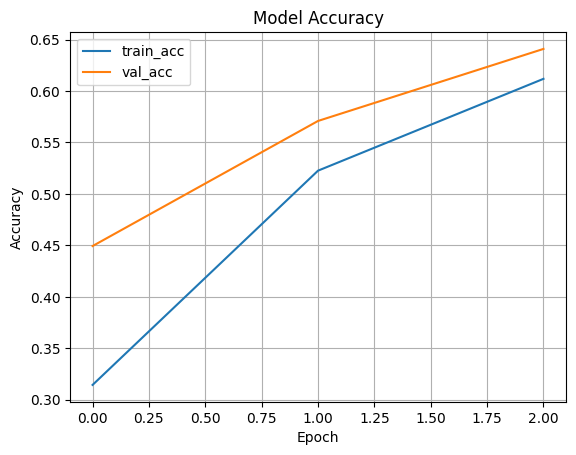

In [ ]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

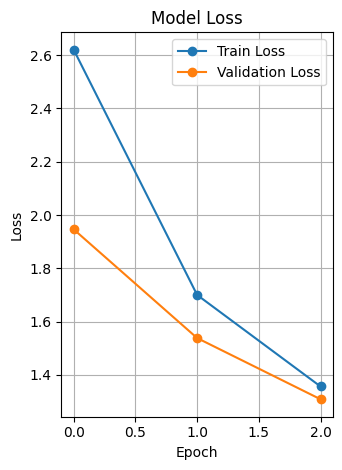

In [ ]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()